# 1) Read a transactions database in sparse format from a txt file into a list of lists. The file contains one transaction per line, each line has a variable number of items, separated by a separator. The external list will have a list for each transaction, each transaction is a list of items. Show the first two transactions (3 points)

In [23]:
import io
f = open("./online_retail_red.txt", "r")
database = [[tr.replace("\n", "") for tr in line.split(";")] for line in f.readlines()]
print(database[0])
print(database[1])

['CREAM CUPID HEARTS COAT HANGER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN']
['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK']


# 2) Encode the list of lists into a binary representation and transform it into a dataframe whose columnsare the items show the head of that dataframe

In [24]:
import pandas as pd
uniques = []

for line in database:
    for transaction in line:
        if transaction not in uniques : uniques.append(transaction)

dataframe = pd.DataFrame(
    data=False,
    index=range(len(database)),
    columns=uniques
)

for i, line in enumerate(database):
    dataframe.loc[i, line] = True

dataframe.head()

,CREAM CUPID HEARTS COAT HANGER,GLASS STAR FROSTED T-LIGHT HOLDER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.,SET 7 BABUSHKA NESTING BOXES,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,HAND WARMER RED POLKA DOT,HAND WARMER UNION JACK,BOX OF 6 ASSORTED COLOUR TEASPOONS,...,WHITE MOROCCAN METAL LANTERN,RED RETRO KITCHEN WALL CLOCK,BICYCLE PUNCTURE REPAIR KIT,CLASSIC BICYCLE CLIPS,GIN AND TONIC DIET METAL SIGN,SET OF 6 RIBBONS COUNTRY STYLE,SNACK TRAY HAPPY FOREST,SNACK TRAY PAISLEY PARK,SNACK TRAY RED VINTAGE DOILY,SET OF 6 RIBBONS PERFECTLY PRETTY
0,True,True,True,True,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# 3) Find a value of min_support such that the apriori algorithm generates at least 8 frequent itemsets with at least 2 items. Output the result with the message below

In [25]:
from mlxtend.frequent_patterns import apriori, association_rules
import numpy as np

step=0.001
min_supports = np.arange(1, 0, -step)
for min_support in min_supports:
    
    frequent_items = apriori(
        df=dataframe, 
        min_support=min_support, 
        use_colnames=True
    )
    
    frequent_itemsets_2_items = len([line for line in frequent_items["itemsets"] if len(line)>=2])
    if frequent_itemsets_2_items >= 8 :
        break

print(f"Min-support: {min_support}")
print(f"There are {frequent_itemsets_2_items} frequent itemssets with at least 2 items")

Min-support: 0.03099999999999914
There are 8 frequent itemssets with at least 2 items


# 4) Find the minimum metric threshold such that at least 10 association rules are extracted from the frequent itemsets found

In [26]:
step=0.001
min_thresholds = np.arange(1, 0, -step) #
for min_threshold in min_thresholds:
    
    rules = association_rules(
        df=frequent_items, 
        min_threshold=min_threshold
    )
    
    ass_rules_extracted = len(rules)
    
    if ass_rules_extracted >= 10:
        break

print(f"Min-threshold: {min_threshold}")
print(f"There are {ass_rules_extracted} association rules extracted")

Min-threshold: 0.5789999999999996
There are 10 association rules extracted


# 5) Print the first 10 rules found, sorted by descending confidence and support

In [34]:
sorted_rules = rules.head(10).sort_values(by=["confidence", "support"], ascending=False).reset_index(drop=True)
sorted_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.039331,0.052255,0.032282,0.820768,15.707077,0.030226,5.287817,0.974669
1,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.052255,0.053541,0.039219,0.750535,14.017835,0.036421,3.793958,0.979865
2,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.053541,0.052255,0.039219,0.732497,14.017835,0.036421,3.542939,0.981197
3,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.064843,0.108426,0.043919,0.677308,6.246751,0.036888,2.762927,0.898156
4,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.049010,0.052031,0.031498,0.642694,12.352165,0.028948,2.653102,0.966406
5,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.050912,0.108426,0.031890,0.626374,5.776988,0.026370,2.386273,0.871257
6,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.052255,0.039331,0.032282,0.617773,15.707077,0.030226,2.513347,0.987960
7,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.063220,0.108426,0.039051,0.617699,5.696983,0.032196,2.332127,0.880109
8,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.052031,0.049010,0.031498,0.605376,12.352165,0.028948,2.409866,0.969486
9,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.063388,0.108426,0.036757,0.579876,5.348148,0.029884,2.122172,0.868043


# 6) Plot confidence and support for all the sorted rules found

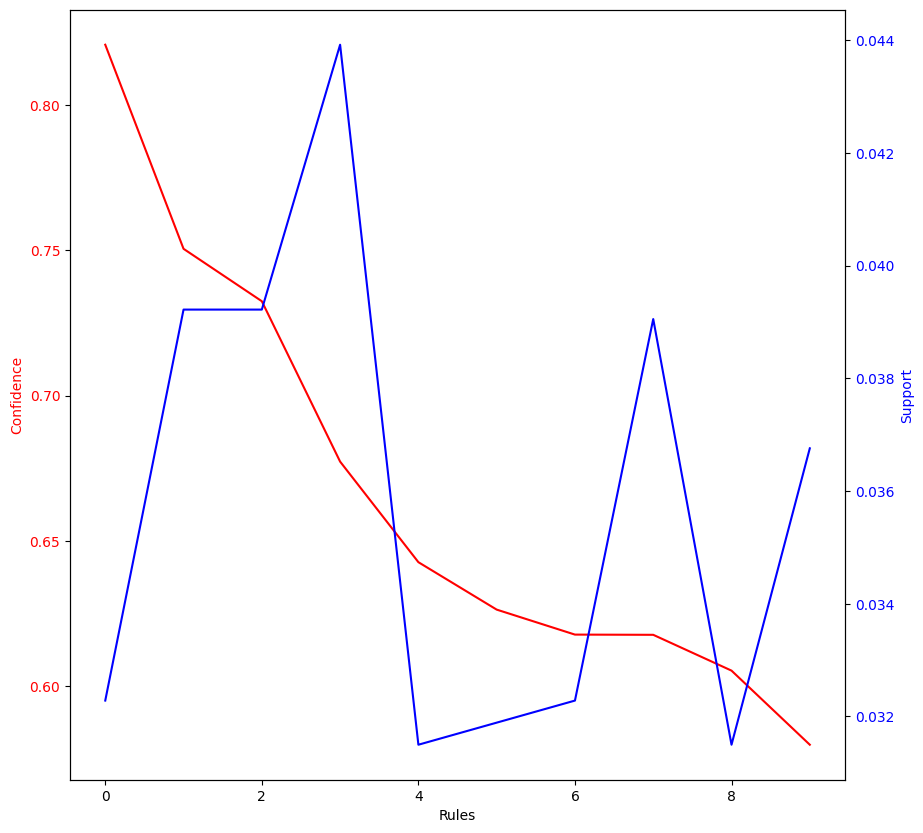

In [44]:
confidences = sorted_rules["confidence"]
supports = sorted_rules["support"]

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(1,1, figsize=[10,10])

ax1.set_xlabel("Rules")
ax1.set_ylabel("Confidence", c="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.plot(confidences, c="r")

ax2 = ax1.twinx()
ax2.set_ylabel("Support", c="b")
ax2.tick_params(axis="y", labelcolor="b")
ax2.plot(supports, c="b")

plt.show()

# 7) Scatter plot the rules by confidence and support, labelling the points with the index value of the corresponding rule

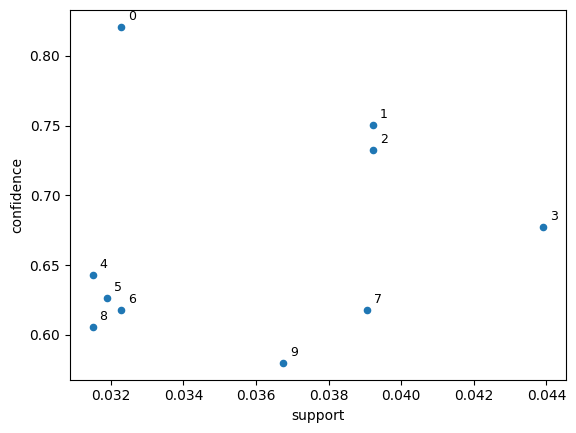

In [55]:
sorted_rules.plot.scatter(x="support", y="confidence");

for i in sorted_rules.index:
    plt.annotate(
        i,
        (sorted_rules["support"].iloc[i], sorted_rules["confidence"].iloc[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )